In [6]:


import pandas as pd

import numpy as np
import xarray as xr
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, TimeDistributed, Flatten, LSTM, Dense, Dropout
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [7]:
from google.colab import files
uploaded = files.upload()


Saving air2mtemp2000_2021_India.nc to air2mtemp2000_2021_India.nc


In [8]:
ds = xr.open_dataset("air2mtemp2000_2021_India.nc")

# Change variable name if needed (air / t2m)
data = ds['air'].values   # shape: (time, lat, lon)

print(data.shape)

(8036, 1, 13, 14)


In [9]:
print(ds['lat'].values)
print(ds['lon'].values)
data = ds['air']   # or 't2m'

# Example: first grid point
point = data[:, 0, 0]

print(point)

[39.047  37.1422 35.2375 33.3328 31.4281 29.5234 27.6186 25.7139 23.8092
 21.9044 19.9997 18.095  16.1902]
[65.625 67.5   69.375 71.25  73.125 75.    76.875 78.75  80.625 82.5
 84.375 86.25  88.125 90.   ]
<xarray.DataArray 'air' (time: 8036, lon: 14)> Size: 450kB
array([[279.93   , 278.09998, 273.81   , ..., 273.59   , 272.93   , 272.06   ],
       [283.41   , 279.28998, 274.     , ..., 273.51   , 272.81   , 271.97   ],
       [284.27002, 281.37   , 275.76   , ..., 272.13   , 270.9    , 269.     ],
       ...,
       [277.5125 , 273.19   , 269.15747, ..., 263.85748, 262.625  , 262.3375 ],
       [281.305  , 275.935  , 272.2075 , ..., 267.595  , 265.97498, 265.4925 ],
       [281.11752, 275.61252, 273.67252, ..., 266.8875 , 263.875  , 266.25   ]],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 64kB 2000-01-01 2000-01-02 ... 2021-12-31
  * lon      (lon) float32 56B 65.62 67.5 69.38 71.25 ... 84.38 86.25 88.12 90.0
    lat      float32 4B 39.05


In [10]:
point = ds['air'].sel(lat=29.523399, lon=78.750, method='nearest')

print(point)

<xarray.DataArray 'air' (time: 8036, level: 1)> Size: 32kB
array([[276.15   ],
       [275.68   ],
       [276.22   ],
       ...,
       [280.3875 ],
       [278.45752],
       [281.24   ]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 64kB 2000-01-01 2000-01-02 ... 2021-12-31
    lat      float32 4B 29.52
    lon      float32 4B 78.75
Dimensions without coordinates: level


In [11]:


lat = ds['lat'].values
lon = ds['lon'].values

lat_idx = np.abs(lat - 29.523399).argmin()
lon_idx = np.abs(lon - 78.750).argmin()

# Corrected: Include the 'level' dimension at index 0
point = ds['air'][:, 0, lat_idx, lon_idx]

print(point)

<xarray.DataArray 'air' (time: 8036)> Size: 32kB
array([276.15   , 275.68   , 276.22   , ..., 280.3875 , 278.45752, 281.24   ],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 64kB 2000-01-01 2000-01-02 ... 2021-12-31
    lat      float32 4B 29.52
    lon      float32 4B 78.75


In [12]:

df = point.to_dataframe().reset_index()
print(df.head())

        time        lat    lon         air
0 2000-01-01  29.523399  78.75  276.149994
1 2000-01-02  29.523399  78.75  275.679993
2 2000-01-03  29.523399  78.75  276.220001
3 2000-01-04  29.523399  78.75  279.049988
4 2000-01-05  29.523399  78.75  279.729980


In [13]:
scaler = MinMaxScaler()

# Squeeze data to remove singleton dimensions, if any, to match expected (t, lat, lon) shape
# This assumes the second dimension of size 1 is extraneous.
if data.ndim == 4 and data.shape[1] == 1:
    data_3d = data.squeeze(axis=1)
else:
    data_3d = data

# reshape to 2D for scaling
t, lat, lon = data_3d.shape
data_reshaped = data_3d.values.reshape(t, -1)

data_scaled = scaler.fit_transform(data_reshaped)

# reshape back
data_scaled = data_scaled.reshape(t, lat, lon)

In [14]:
def create_dataset(dataset, time_step=5):
    X, y = [], []

    for i in range(len(dataset) - time_step):
        X.append(dataset[i:i+time_step])
        y.append(dataset[i+time_step])

    return np.array(X), np.array(y)

time_step = 5
X, y = create_dataset(data_scaled, time_step)

print(X.shape, y.shape)

(8031, 5, 13, 14) (8031, 13, 14)


In [15]:
# Add channel dimension
X = X.reshape(X.shape[0], time_step, lat, lon, 1)
y = y.reshape(y.shape[0], lat, lon, 1)

In [16]:

model = Sequential()

# CNN applied at each time step
model.add(TimeDistributed(
    Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
    input_shape=(time_step, lat, lon, 1)
))

model.add(TimeDistributed(Flatten()))

# LSTM layer
model.add(LSTM(128,return_sequences=True ,activation='relu'))

model.add(LSTM(64, return_sequences=True,activation='relu'))

model.add(LSTM(32))
# Explicitly set return_sequences=False

# Output layer
model.add(Dense(lat * lon))

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 5, 11, 12, 32)  │           320 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 5, 4224)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 5, 128)         │     2,228,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 5, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 182)            │         6,006 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,296,886 (8.76 MB)

 Trainable params: 2,296,886 (8.76 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# We need to reshape y for train_test_split to handle it correctly
X_train, X_test, y_train, y_test = train_test_split(X, y.reshape(y.shape[0], -1), test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (6424, 5, 13, 14, 1)
X_test shape: (1607, 5, 13, 14, 1)
y_train shape: (6424, 182)
y_test shape: (1607, 182)


In [21]:
history = model.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_test, y_test))

Epoch 1/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - loss: 0.0031 - val_loss: 0.0033
Epoch 2/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - loss: 0.0029 - val_loss: 0.0029
Epoch 3/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 4/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - loss: 0.0027 - val_loss: 0.0028
Epoch 5/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 6/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - loss: 0.0025 - val_loss: 0.0026
Epoch 7/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - loss: 0.0025 - val_loss: 0.0026
Epoch 8/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - loss: 0.0024 - val_loss: 0.0027
Epoch 9/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - loss: 0.0024 - val_loss: 0.0025
Epoch 10/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 11/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - loss: 0.0023 - val_loss: 0.0024
Epoch 12/100
803/80

In [22]:
y_pred = model.predict(X_test)

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [23]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 0.002443750388920307


In [24]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

0.049434303766921886


In [25]:
y_pred_actual = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test)

In [26]:
print(y_pred_actual[:10])

[[301.6926  297.39618 291.60992 ... 301.3267  301.2579  301.13583]
 [293.84637 287.8271  277.03885 ... 302.2272  302.61804 302.6477 ]
 [293.1707  287.4938  278.31342 ... 301.56445 301.8118  301.7481 ]
 ...
 [286.6459  284.1367  277.91916 ... 301.3227  301.52536 301.7314 ]
 [288.54227 285.77316 279.7564  ... 301.84607 302.00323 302.18854]
 [286.37613 281.11823 273.74377 ... 300.20822 300.41098 300.38116]]


In [27]:
n = 3  # number of values to show from start and end

# First n values
for i in range(n):
    print(f"Actual: {y_test_actual[i]}, Predicted: {y_pred_actual[i]}")

print("...")  # to indicate skipped values

# Last n values
for i in range(len(y_test_actual) - n, len(y_test_actual)):
    print(f"Actual: {y_test_actual[i]}, Predicted: {y_pred_actual[i]}")

Actual: [296.31    293.45    289.39    284.5     280.64    279.78    282.51
 287.2     289.97998 292.34    292.15    290.86    290.18    288.91998
 295.08002 292.9     290.41998 284.83002 280.18    277.28    279.24
 282.47    286.39    287.08002 285.95    284.16998 283.44    283.37
 295.01    294.51    293.49    290.18    285.68    274.84    273.24
 276.96    278.11    279.26    278.77002 278.97    279.55    280.33002
 297.61    297.08002 296.47998 297.93    295.21    289.8     283.57
 278.5     275.95    274.57    274.61    275.77002 276.72    277.66998
 297.66998 300.27002 302.3     304.37    304.58002 300.72    294.78
 288.02002 281.75    277.41    275.66    275.59    276.07    278.12
 299.93    304.16998 305.8     306.96    307.41998 306.46    302.68
 296.34    289.99    285.16998 281.72998 279.91    279.8     281.38
 305.45    307.37    307.74    306.83002 303.84    303.21    302.25
 300.36    297.65    293.78    289.8     287.71    287.31    288.36
 304.49    306.62    307.7     

In [29]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)
# Inverse transform
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [30]:
pred = model.predict(X)

# reshape back to grid
pred = pred.reshape(pred.shape[0], lat, lon)

print(pred.shape)

251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
(8031, 13, 14)


In [31]:
from sklearn.metrics import mean_squared_error
import math


# Reshape y and pred to 2D for inverse scaling (n_samples, n_features) and then flatten for MSE calculation
actual_original_scale = scaler.inverse_transform(y.reshape(y.shape[0], -1))
predicted_original_scale = scaler.inverse_transform(pred.reshape(pred.shape[0], -1))

rmse = math.sqrt(mean_squared_error(
    actual_original_scale,
    predicted_original_scale
))

print("RMSE:", rmse)

# Use data_3d for min/max to calculate RMSE percentage on original scale
rmse_percent = (rmse / (data_3d.max() - data_3d.min())) * 100
print("RMSE %:", rmse_percent)

RMSE: 1.3799659612161799
RMSE %: <xarray.DataArray 'air' ()> Size: 8B
array(1.52532988)


In [32]:
# Make predictions on the training and testing sets
train_pred_scaled = model.predict(X_train)
test_pred_scaled = model.predict(X_test)

print(f"train_pred_scaled shape: {train_pred_scaled.shape}")
print(f"test_pred_scaled shape: {test_pred_scaled.shape}")

201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
train_pred_scaled shape: (6424, 182)
test_pred_scaled shape: (1607, 182)


In [33]:
from sklearn.metrics import mean_squared_error
import math

# Inverse transform the predictions and actual values for both train and test sets
# Note: y_train and y_test are already reshaped in train_test_split

train_pred_original = scaler.inverse_transform(train_pred_scaled)
y_train_original = scaler.inverse_transform(y_train)

test_pred_original = scaler.inverse_transform(test_pred_scaled)
y_test_original = scaler.inverse_transform(y_test)

# Calculate RMSE for training set
rmse_train = math.sqrt(mean_squared_error(y_train_original, train_pred_original))
print(f"Train RMSE: {rmse_train}")

# Calculate RMSE for testing set
rmse_test = math.sqrt(mean_squared_error(y_test_original, test_pred_original))
print(f"Test RMSE: {rmse_test}")

# Calculate RMSE percentage for training set
rmse_train_percent = (rmse_train / (data_3d.max() - data_3d.min())) * 100
print(f"Train RMSE %: {rmse_train_percent}")

# Calculate RMSE percentage for testing set
rmse_test_percent = (rmse_test / (data_3d.max() - data_3d.min())) * 100
print(f"Test RMSE %: {rmse_test_percent}")

Train RMSE: 1.2437226508119241
Test RMSE: 1.8257215301579737
Train RMSE %: <xarray.DataArray 'air' ()> Size: 8B
array(1.37473487)
Test RMSE %: <xarray.DataArray 'air' ()> Size: 8B
array(2.01804079)


In [34]:
# Compare train and test RMSE to diagnose underfitting/overfitting
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")

# Define thresholds for assessment (these can be adjusted based on your domain knowledge)
rmse_diff_threshold = 0.1 # Absolute difference between train and test RMSE
high_rmse_threshold = 2.0 # Absolute RMSE value considered 'high'

if rmse_train > high_rmse_threshold and rmse_test > high_rmse_threshold:
    print("\nAssessment: The model might be *underfitting*. Both train and test RMSE are relatively high, indicating the model is not capturing the underlying patterns in the data well.")
elif rmse_train < rmse_test and (rmse_test - rmse_train) > rmse_diff_threshold:
    print(f"\nAssessment: The model might be *overfitting*. The test RMSE ({rmse_test:.4f}) is significantly higher than the train RMSE ({rmse_train:.4f}), suggesting the model learned the training data too well but struggles with unseen data.")
elif rmse_train <= rmse_test and (rmse_test - rmse_train) <= rmse_diff_threshold:
    print("\nAssessment: The model appears to be *well-fitted*. Both train and test RMSE are low and similar, indicating good generalization performance.")
else:
    print("\nAssessment: The model's fit is *acceptable*. The difference between train and test RMSE is small, and the overall RMSE values are reasonable.")


Train RMSE: 1.2437
Test RMSE: 1.8257

Assessment: The model might be *overfitting*. The test RMSE (1.8257) is significantly higher than the train RMSE (1.2437), suggesting the model learned the training data too well but struggles with unseen data.


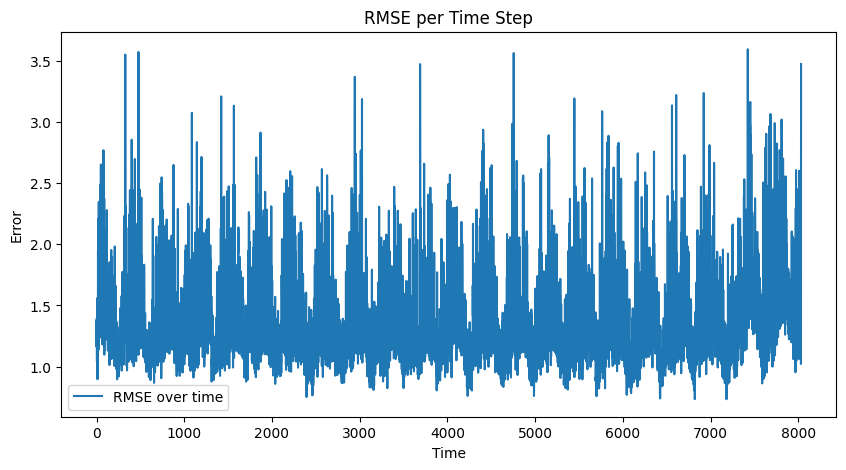

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate error at each point across the lat*lon grid for each time step
errors_per_timestep = actual_original_scale - predicted_original_scale

# Calculate RMSE per time step by taking the mean of squared errors across the spatial dimensions
rmse_series = np.sqrt(np.mean(errors_per_timestep**2, axis=1))

plt.figure(figsize=(10,5))
plt.plot(rmse_series, label="RMSE over time")
plt.title("RMSE per Time Step")
plt.xlabel("Time")
plt.ylabel("Error")
plt.legend()
plt.show()

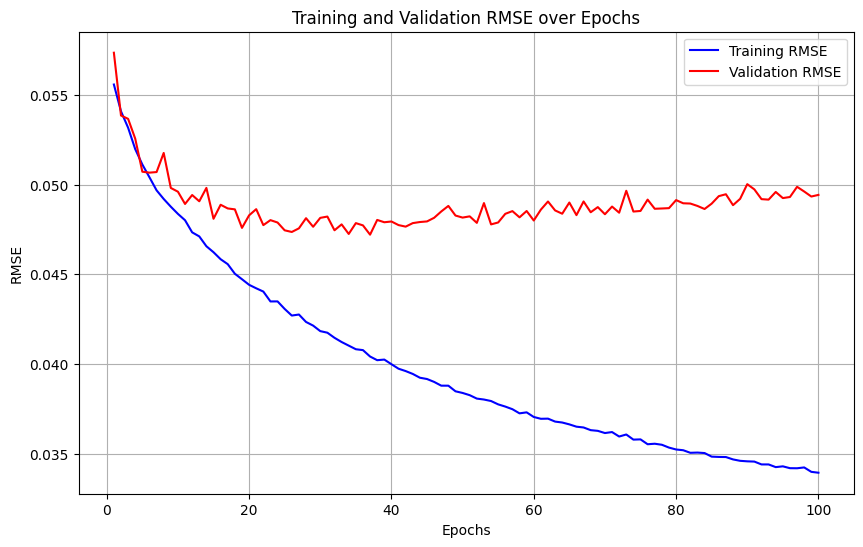

In [36]:
import matplotlib.pyplot as plt

# Get the training and validation loss (MSE in this case)
train_mse = history.history['loss']
val_mse = history.history['val_loss']

# Calculate RMSE from MSE
train_rmse = np.sqrt(train_mse)
val_rmse = np.sqrt(val_mse)

epochs = range(1, len(train_rmse) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_rmse, 'b', label='Training RMSE')
plt.plot(epochs, val_rmse, 'r', label='Validation RMSE')
plt.title('Training and Validation RMSE over Epochs')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.show()

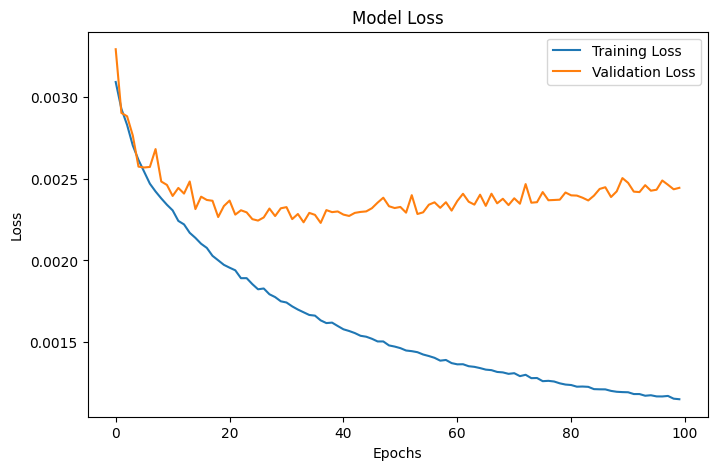

In [37]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.show()

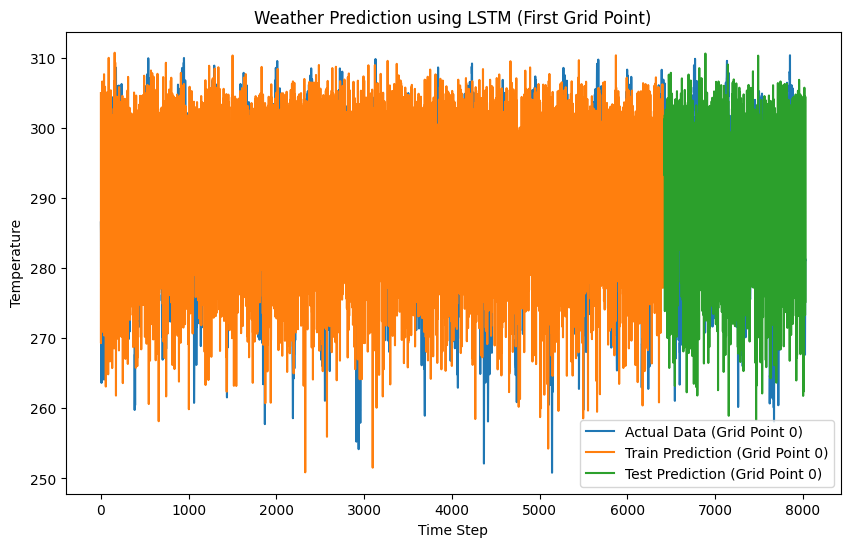

In [39]:
plt.figure(figsize=(10,6))
plt.plot(actual_original_scale[:, 0], label='Actual Data (Grid Point 0)')
plt.plot(range(len(train_predict)), train_predict[:, 0], label='Train Prediction (Grid Point 0)')
plt.plot(range(len(train_predict), len(train_predict)+len(test_predict)), test_predict[:, 0], label='Test Prediction (Grid Point 0)')

plt.legend()
plt.title("Weather Prediction using LSTM (First Grid Point)")
plt.xlabel("Time Step")
plt.ylabel("Temperature")
plt.show()

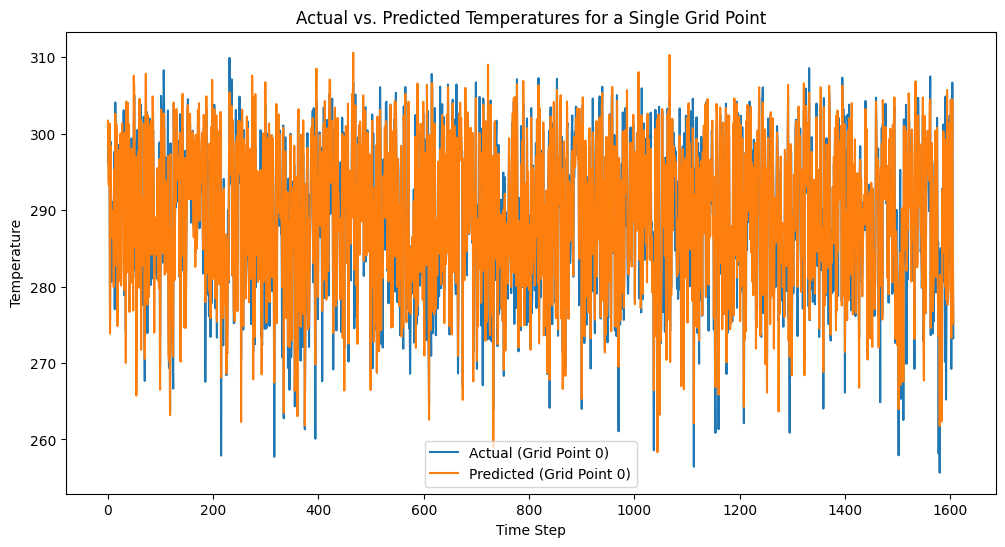

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test_actual[:, 0], label="Actual (Grid Point 0)")
plt.plot(y_pred_actual[:, 0], label="Predicted (Grid Point 0)")
plt.title("Actual vs. Predicted Temperatures for a Single Grid Point")
plt.xlabel("Time Step")
plt.ylabel("Temperature")
plt.legend()
plt.show()